In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/titanic.csv")
print(df.shape)
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

(891, 12)
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


**Handle missing values (different strategies for different reasons)**

In [3]:
# Age — 177 missing (19.9%) — moderate missingness
# Strategy: impute with median, grouped by Pclass + Sex (smarter than overall median)

age_by_group = df.groupby(["Pclass", "Sex"])["Age"].median()
print("Median age by Pclass & Sex:")
print(age_by_group)

df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(
    lambda x: x.fillna(x.median())
)
print(f"\nAge missing after imputation: {df['Age'].isnull().sum()}")

Median age by Pclass & Sex:
Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

Age missing after imputation: 0


**Cabin: too many missing, engineer a new feature instead**

In [4]:
# Cabin — 687 missing (77%) — too sparse to impute meaningfully
# Strategy: extract whether cabin is known at all — that itself is informative
# (Higher class passengers had recorded cabins more often)

df["HasCabin"] = df["Cabin"].notnull().astype(int)
print(df["HasCabin"].value_counts())

# Survival rate by HasCabin — sanity check that this feature matters
print("\nSurvival rate by HasCabin:")
print(df.groupby("HasCabin")["Survived"].mean())

HasCabin
0    687
1    204
Name: count, dtype: int64

Survival rate by HasCabin:
HasCabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64


**Embarked: only 2 missing, simple mode fill**

In [5]:
# Embarked — only 2 missing — safe to fill with mode (most common value)
print(df["Embarked"].value_counts())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
print(f"\nEmbarked missing after fill: {df['Embarked'].isnull().sum()}")

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Embarked missing after fill: 0


**Now let's encode categorical variables**

In [6]:
# Sex — binary, use Label Encoding (0/1)
df["Sex_encoded"] = df["Sex"].map({"male": 0, "female": 1})

# Embarked — 3 categories, no natural order, use One-Hot Encoding
embarked_dummies = pd.get_dummies(df["Embarked"], prefix="Embarked", drop_first=True)
df = pd.concat([df, embarked_dummies], axis=1)

# Pclass — already numeric (1,2,3) but it's actually categorical (ordinal)
# Keep as-is since 1 < 2 < 3 has meaningful order (ticket class)

print(df[["Sex", "Sex_encoded", "Embarked", "Embarked_Q", "Embarked_S", "Pclass"]].head(8))

      Sex  Sex_encoded Embarked  Embarked_Q  Embarked_S  Pclass
0    male            0        S       False        True       3
1  female            1        C       False       False       1
2  female            1        S       False        True       3
3  female            1        S       False        True       1
4    male            0        S       False        True       3
5    male            0        Q        True       False       3
6    male            0        S       False        True       1
7    male            0        S       False        True       3


 **Feature engineering: create new features**

In [7]:
# Family size — combine SibSp + Parch
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1  # +1 for the passenger themselves

# IsAlone — binary flag
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# Title extraction from Name — Mr, Mrs, Miss, Master carry social info
df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.")
print(df["Title"].value_counts())

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


**Clean up Title into meaningful groups**

In [8]:
# Group rare titles together — too many categories = noisy feature
title_mapping = {
    "Mr": "Mr",
    "Miss": "Miss",
    "Mrs": "Mrs",
    "Master": "Master",
    "Mlle": "Miss",      # French for Miss
    "Ms": "Miss",
    "Mme": "Mrs",        # French for Mrs
}

df["Title"] = df["Title"].map(title_mapping).fillna("Rare")
print(df["Title"].value_counts())

# Survival rate by Title — check if this feature is informative
print("\nSurvival rate by Title:")
print(df.groupby("Title")["Survived"].mean().sort_values(ascending=False))

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

Survival rate by Title:
Title
Mrs       0.793651
Miss      0.702703
Master    0.575000
Rare      0.347826
Mr        0.156673
Name: Survived, dtype: float64


**Handle skewed Fare distribution**

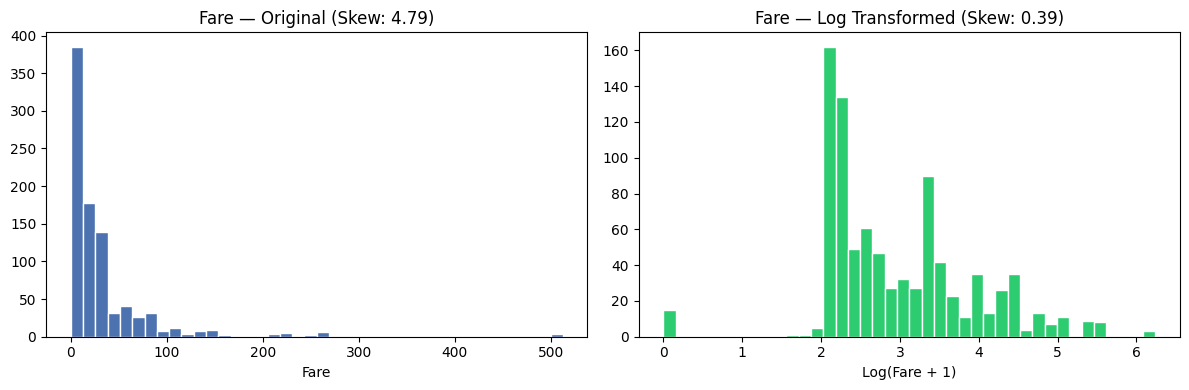

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Fare"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title(f"Fare — Original (Skew: {df['Fare'].skew():.2f})")
axes[0].set_xlabel("Fare")

# Log transform to fix right-skew
df["Fare_log"] = np.log1p(df["Fare"])  # log1p handles zero values safely

axes[1].hist(df["Fare_log"], bins=40, color="#2ecc71", edgecolor="white")
axes[1].set_title(f"Fare — Log Transformed (Skew: {df['Fare_log'].skew():.2f})")
axes[1].set_xlabel("Log(Fare + 1)")

plt.tight_layout()
plt.savefig("../output/fare_skew_transform.png", dpi=150)
plt.show()

**Correlation heatmap**

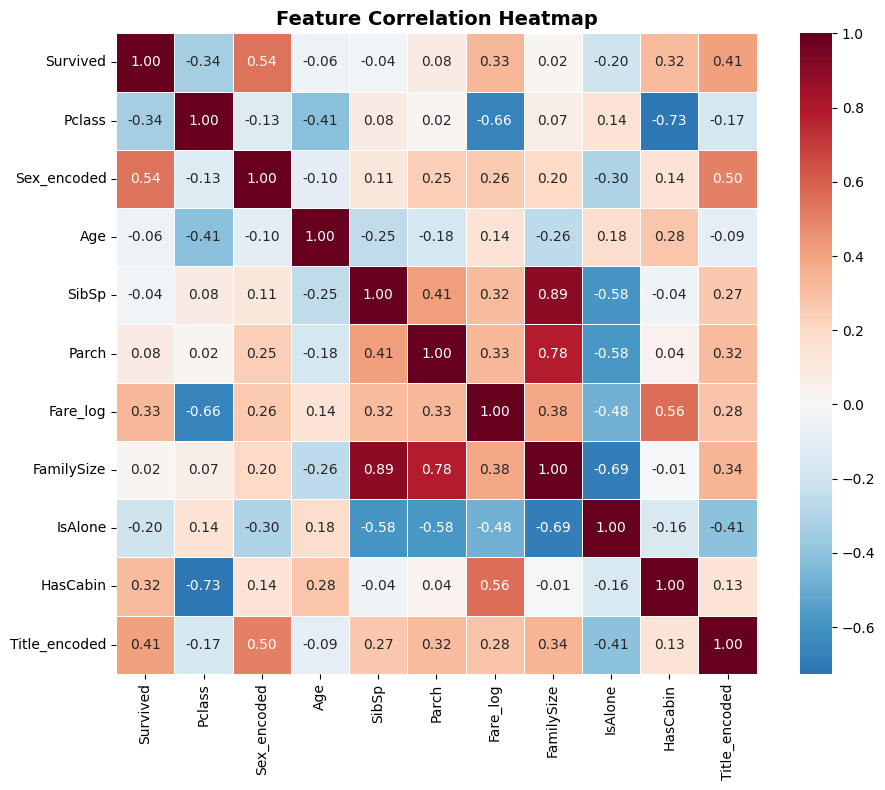


Correlation with Survived (sorted):
Survived         1.000000
Sex_encoded      0.543351
Title_encoded    0.407753
Fare_log         0.329862
HasCabin         0.316912
Parch            0.081629
FamilySize       0.016639
SibSp           -0.035322
Age             -0.059579
IsAlone         -0.203367
Pclass          -0.338481
Name: Survived, dtype: float64


In [10]:
df["Title_encoded"] = df["Title"].map({
    "Mr": 0, "Miss": 1, "Mrs": 2, "Master": 3, "Rare": 4
})

features = ["Survived", "Pclass", "Sex_encoded", "Age", "SibSp", "Parch",
            "Fare_log", "FamilySize", "IsAlone", "HasCabin", "Title_encoded"]

corr = df[features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../output/titanic_correlation.png", dpi=150)
plt.show()

print("\nCorrelation with Survived (sorted):")
print(corr["Survived"].sort_values(ascending=False))

**SelectKBest — statistical feature selection**

In [11]:
from sklearn.feature_selection import SelectKBest, f_classif

X = df[["Pclass", "Sex_encoded", "Age", "SibSp", "Parch",
        "Fare_log", "FamilySize", "IsAlone", "HasCabin", "Title_encoded"]]
y = df["Survived"]

selector = SelectKBest(score_func=f_classif, k="all")
selector.fit(X, y)

scores_df = pd.DataFrame({
    "Feature": X.columns,
    "F_Score": selector.scores_,
    "P_Value": selector.pvalues_
}).sort_values("F_Score", ascending=False)

print(scores_df.to_string(index=False))

      Feature    F_Score      P_Value
  Sex_encoded 372.405724 1.406066e-69
Title_encoded 177.283027 5.153081e-37
       Pclass 115.031272 2.537047e-25
     Fare_log 108.541519 4.646670e-24
     HasCabin  99.253142 3.090891e-22
      IsAlone  38.353651 9.009490e-10
        Parch   5.963464 1.479925e-02
          Age   3.166926 7.548531e-02
        SibSp   1.110572 2.922439e-01
   FamilySize   0.246193 6.198911e-01


In [12]:
# Cell 11 — Final feature selection based on analysis
final_features = ["Pclass", "Sex_encoded", "Title_encoded", "Fare_log", 
                   "HasCabin", "IsAlone", "Age"]

X_final = df[final_features]
y_final = df["Survived"]

print(f"Final feature set: {final_features}")
print(f"Dropped due to multicollinearity: SibSp, Parch, FamilySize (kept IsAlone instead)")
print(f"\nShape: {X_final.shape}")

Final feature set: ['Pclass', 'Sex_encoded', 'Title_encoded', 'Fare_log', 'HasCabin', 'IsAlone', 'Age']
Dropped due to multicollinearity: SibSp, Parch, FamilySize (kept IsAlone instead)

Shape: (891, 7)
